# Genre Operational Synergy

The investment firm wants to identify which game genres have the strongest operational synergy based on publisher portfolios.

For this analysis, operational synergy is measured using cosine similarity of publisher title-count portfolios. Genres with similar publisher title distributions are treated as more closely related.


Strongest genre pair: Adventure + Casual
Synergy score: 0.724


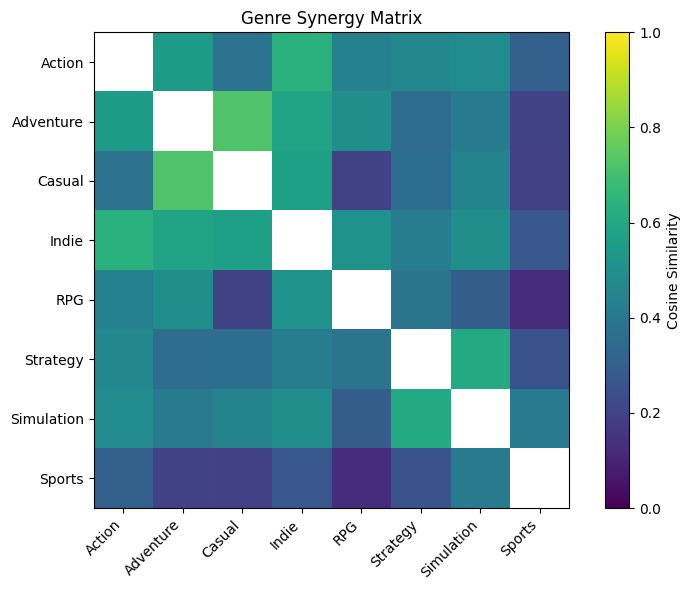

In [ ]:
import numpy as np
import pandas as pd


STEAM_PATH = "../../data/steam/steam.csv"

GENRES = [
    "Action", "Adventure", "Casual", "Indie",
    "RPG", "Strategy", "Simulation", "Sports",
]


steam = pd.read_csv(STEAM_PATH)


# Expand genre and publisher assignments.
data = (
    steam.assign(
        genre=steam["genres"].fillna("").str.split(";"),
        publisher_name=steam["publisher"].fillna("").str.split(";"),
    )
    .explode("genre")
    .explode("publisher_name")
)

data["genre"] = data["genre"].str.strip()
data["publisher_name"] = data["publisher_name"].str.strip()

data = data[
    data["genre"].isin(GENRES)
    & data["publisher_name"].ne("")
].drop_duplicates(
    ["appid", "publisher_name", "genre"]
)


# Publisher × genre title counts.
title_matrix = (
    data.groupby(
        ["publisher_name", "genre"]
    )["appid"]
    .nunique()
    .unstack(fill_value=0)
    .reindex(
        columns=GENRES,
        fill_value=0,
    )
)


# Cosine similarity between genres.
x = title_matrix.to_numpy()

similarity = (
    x.T @ x
) / np.outer(
    np.linalg.norm(x, axis=0),
    np.linalg.norm(x, axis=0),
)

np.fill_diagonal(
    similarity,
    np.nan,
)


# Strongest genre pair.
i, j = np.unravel_index(
    np.nanargmax(similarity),
    similarity.shape,
)

genre_1 = GENRES[i]
genre_2 = GENRES[j]
score = similarity[i, j]


print(
    "Strongest genre pair:",
    f"{genre_1} + {genre_2}",
)

print(
    "Synergy score:",
    f"{score:.3f}",
)

import matplotlib.pyplot as plt


fig, ax = plt.subplots(
    figsize=(8, 6)
)

image = ax.imshow(
    similarity,
    vmin=0,
    vmax=1,
)

ax.set_xticks(
    range(len(GENRES)),
    GENRES,
    rotation=45,
    ha="right",
)

ax.set_yticks(
    range(len(GENRES)),
    GENRES,
)

ax.set_title(
    "Genre Synergy Matrix"
)

fig.colorbar(
    image,
    ax=ax,
    label="Cosine Similarity",
)

plt.tight_layout()
plt.show()

## Conclusion

Adventure and Casual exhibit the strongest operational synergy, with a cosine similarity score of approximately **0.724**.

This indicates that the two genres have the most similar publisher title-count portfolios among the genres analyzed.
